In [101]:
# Import packages
from concurrent.futures import ThreadPoolExecutor
from os import listdir, mkdir
from subprocess import check_output

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio as rio
import seaborn as sns
from keras import Sequential
from keras.layers import Dense
from pyearth import Earth
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, root_mean_squared_error
from sklearn.svm import SVR
from xgboost import XGBRegressor

In [102]:
# Parameter
FEATURES = ["logBLUE", "logGREEN"]
LABEL = "AGC"

# Log image location
LOG_PATH = (
    "https://storage.googleapis.com/gee-ramiqcom-bucket/blueCarbon/sample/sample_"
)

# Sample path
SAMPLE_PATH = "https://storage.googleapis.com/gee-ramiqcom-bucket/blueCarbon/multitemporal_sample.csv"

# File format
SUFFIX = ".csv"

# Year list
YEARS = [2019, 2020, 2021]

# Months
MONTHS = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]

# REGIONS list
REGIONS = [
    "Banda_Neira",
    "Belitung",
    "Biak",
    "Bunaken",
    "Derawan",
    "Gorontalo",
    "Kapota",
    "Labuan_Bajo",
    "Lombok_Selatan",
    "Mentawai",
    "Parang",
    "Rote",
    "Ujung_Kulon",
]

# Region names
TEST = [
    {"region": "Labuan_Bajo", "month": [3, 4, 5, 6], "year": [2019]},
    {"region": "Parang", "month": [3, 4], "year": [2019]},
    {"region": "Lombok_Selatan", "month": [9, 10], "year": [2019]},
    {"region": "Rote", "month": [9, 10], "year": [2021]},
]

In [103]:
# Sample data
data = [
    {"AGC": 0, "Keterangan": "100% sand Bajo", "logBLUE": 7.05, "logGREEN": 7.18},
    {"AGC": 0, "Keterangan": "100% sand Belitung", "logBLUE": 6.63, "logGREEN": 6.88},
    {"AGC": 0, "Keterangan": "100% sand Biak", "logBLUE": 7.32, "logGREEN": 7.42},
    {"AGC": 0, "Keterangan": "100% sand Bunaken", "logBLUE": 7.05, "logGREEN": 7.08},
    {"AGC": 0, "Keterangan": "100% sand Derawan", "logBLUE": 7.36, "logGREEN": 7.45},
    {"AGC": 0, "Keterangan": "100% sand Gorontalo", "logBLUE": 6.72, "logGREEN": 7.15},
    {"AGC": 0, "Keterangan": "100% sand Kapota", "logBLUE": 7.29, "logGREEN": 7.45},
    {"AGC": 0, "Keterangan": "100% sand Mandalika", "logBLUE": 6.92, "logGREEN": 7.09},
    {"AGC": 0, "Keterangan": "100% sand Mentawai", "logBLUE": 6.96, "logGREEN": 7.11},
    {
        "AGC": 0,
        "Keterangan": "100% sand Parang Field/Visual",
        "logBLUE": 6.72,
        "logGREEN": 6.89,
    },
    {"AGC": 0, "Keterangan": "100% sand Rote", "logBLUE": 7.45, "logGREEN": 7.51},
    {"AGC": 0, "Keterangan": "100% sand Panaitan", "logBLUE": 7.33, "logGREEN": 7.34},
    {
        "AGC": 44.9,
        "Keterangan": "100% seagrass TWP Padaido",
        "logBLUE": 3.37,
        "logGREEN": 5.50,
    },
    {
        "AGC": 44.9,
        "Keterangan": "100% seagrass Kwandang",
        "logBLUE": 4.98,
        "logGREEN": 5.61,
    },
    {
        "AGC": 44.9,
        "Keterangan": "100% seagrass Siberut",
        "logBLUE": 2.55,
        "logGREEN": 5.25,
    },
    {
        "AGC": 44.9,
        "Keterangan": "100% seagrass Parang Island (from field data)",
        "logBLUE": 4.69,
        "logGREEN": 5.45,
    },
    {
        "AGC": 44.9,
        "Keterangan": "100% seagrass Rote Island (combined)",
        "logBLUE": 4.69,
        "logGREEN": 5.45,
    },
    {
        "AGC": 44.9,
        "Keterangan": "100% seagrass Panaitan Island",
        "logBLUE": 1.76,
        "logGREEN": 4.61,
    },
    {
        "AGC": 44.9,
        "Keterangan": "100% seagrass Panaitan Island (combined)",
        "logBLUE": 4.77,
        "logGREEN": 5.02,
    },
]
data = pd.DataFrame.from_records(data)
data

,AGC,Keterangan,logBLUE,logGREEN
0,0.0,100% sand Bajo,7.05,7.18
1,0.0,100% sand Belitung,6.63,6.88
2,0.0,100% sand Biak,7.32,7.42
3,0.0,100% sand Bunaken,7.05,7.08
4,0.0,100% sand Derawan,7.36,7.45
5,0.0,100% sand Gorontalo,6.72,7.15
6,0.0,100% sand Kapota,7.29,7.45
7,0.0,100% sand Mandalika,6.92,7.09
8,0.0,100% sand Mentawai,6.96,7.11
9,0.0,100% sand Parang Field/Visual,6.72,6.89


In [104]:
# Turn into np array for input and output
input = data[FEATURES]
output = data[LABEL]

In [105]:
# Random Forest Regressor
rf = RandomForestRegressor(50)
rf.fit(input, output)
print(rf.feature_importances_)

# Predict its own
rf_model = rf.predict(input)
r2_rf_model = np.corrcoef(output, rf_model)[0, 1] ** 2
rmse_rf_model = root_mean_squared_error(output, rf_model)
print(f"RF\nR^2={r2_rf_model}\nRMSE={rmse_rf_model}")

# Linear regression
lr = LinearRegression()
lr.fit(input, output)

# Predict its own
lr_model = lr.predict(input)
r2_lr_model = np.corrcoef(output, lr_model)[0, 1] ** 2
rmse_lr_model = root_mean_squared_error(output, lr_model)
print(f"LR\nR^2={r2_lr_model}\nRMSE={rmse_lr_model}")

# XGBoost
xgboost = XGBRegressor(n_estimator=100)
xgboost.fit(input, output)

# SVM
svm_model = SVR(kernel="poly")
svm_model.fit(input, output)

# Predict its own
svm_model_result = svm_model.predict(input)
r2_svm_model = np.corrcoef(output, svm_model_result)[0, 1] ** 2
rmse_svm_model = root_mean_squared_error(output, svm_model_result)
print(f"SVM\nR^2={r2_svm_model}\nRMSE={rmse_svm_model}")

# Mars
mars = Earth()
mars.fit(input, output)

# Predict its own
mars_model = mars.predict(input)
r2_mars_model = np.corrcoef(output, mars_model)[0, 1] ** 2
rmse_mars_model = root_mean_squared_error(output, mars_model)
print(f"MARS\nR^2={r2_mars_model}\nRMSE={rmse_mars_model}")


# Step wise
def stepwise(logGREEN):
    return 155.34 - (21.383 * logGREEN)


# Predict its own
stepwise_model = stepwise(input["logGREEN"])
r2_stepwise_model = np.corrcoef(output, stepwise_model)[0, 1] ** 2
rmse_stepwise_model = root_mean_squared_error(output, stepwise_model)
print(f"Stepwise\nR^2={r2_stepwise_model}\nRMSE={rmse_stepwise_model}")

[0.48 0.52]
RF
R^2=1.0
RMSE=2.1564154148268387e-14
LR
R^2=0.9307487175225592
RMSE=5.699625139769957
SVM
R^2=0.9346857156450565
RMSE=6.421621754860515
MARS
R^2=0.9461772928394765
RMSE=5.0247580205145
Stepwise
R^2=0.930031540196805
RMSE=5.731480927670669


# Deep Learning Model


In [106]:
# Build model
model = Sequential(
    [
        Dense(64, activation="relu"),
        Dense(1, activation="relu"),
    ]
)
model.summary()

# Compile model
model.compile(optimizer="Adam", loss="mse", metrics=["MeanSquaredError"])

# Fit model
model.fit(
    x=input / 7.5,
    y=output / 44.9,
    epochs=50,
    batch_size=1,
)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - MeanSquaredError: 0.3053 - loss: 0.3053  
Epoch 2/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 956us/step - MeanSquaredError: 0.2927 - loss: 0.2927
Epoch 3/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - MeanSquaredError: 0.2859 - loss: 0.2859
Epoch 4/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - MeanSquaredError: 0.2843 - loss: 0.2843
Epoch 5/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - MeanSquaredError: 0.2751 - loss: 0.2751 
Epoch 6/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - MeanSquaredError: 0.2702 - loss: 0.2702
Epoch 7/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - MeanSquaredError: 0.2609 - loss: 0.2609 
Epoch 8/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - MeanSquaredError: 0.2547 - loss: 0.2547
Epoch 9/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 936us/step - MeanSquaredError: 0.2498 - loss: 0.2498
Epoch 10/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 551us/step - MeanSquaredError: 0.2429 - loss: 0.2429
Epoch 11/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 839us/step - MeanSquaredErr

In [107]:
# Function to predict deep learning
def deep_learning(logData):
    return model.predict(logData / 7.5, batch_size=4096 * 10).flatten() * 44.9


# Predict its own
dl_model = deep_learning(input)
r2_dl_model = np.corrcoef(output, dl_model)[0, 1] ** 2
rmse_dl_model = root_mean_squared_error(output, dl_model)
print(f"Deep learning\nR^2={r2_dl_model}\nRMSE={rmse_dl_model}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
Deep learning
R^2=0.8147304739148811
RMSE=11.563269232353472


# Apply Model to Image


## List of file


In [108]:
# List of files
files = check_output(
    "gcloud storage ls gs://gee-ramiqcom-bucket/seagrass/log_image/*.tif",
    shell=True,
    text=True,
).split("\n")[:-1]
files = [path.replace("gs://", "https://storage.googleapis.com/") for path in files]
files

['https://storage.googleapis.com/gee-ramiqcom-bucket/seagrass/log_image/Banda_Neira_bimonthly_2019_1.tif',
 'https://storage.googleapis.com/gee-ramiqcom-bucket/seagrass/log_image/Banda_Neira_bimonthly_2019_11.tif',
 'https://storage.googleapis.com/gee-ramiqcom-bucket/seagrass/log_image/Banda_Neira_bimonthly_2019_3.tif',
 'https://storage.googleapis.com/gee-ramiqcom-bucket/seagrass/log_image/Banda_Neira_bimonthly_2019_5.tif',
 'https://storage.googleapis.com/gee-ramiqcom-bucket/seagrass/log_image/Banda_Neira_bimonthly_2019_7.tif',
 'https://storage.googleapis.com/gee-ramiqcom-bucket/seagrass/log_image/Banda_Neira_bimonthly_2019_9.tif',
 'https://storage.googleapis.com/gee-ramiqcom-bucket/seagrass/log_image/Banda_Neira_bimonthly_2020_1.tif',
 'https://storage.googleapis.com/gee-ramiqcom-bucket/seagrass/log_image/Banda_Neira_bimonthly_2020_11.tif',
 'https://storage.googleapis.com/gee-ramiqcom-bucket/seagrass/log_image/Banda_Neira_bimonthly_2020_3.tif',
 'https://storage.googleapis.com/ge

## Apply model to the file


In [109]:
svm_folder = "svm"

try:
    mkdir(svm_folder)
except Exception as e:
    print(e)


def run_svm_model(location: str, shape: tuple[int, int]):
    path_name = location.split("/")[-1]
    with rio.open(location) as src:
        # Read the geotiff metadata
        profile = src.profile
        bands = src.count

        # Read the geotiff as numpy array
        raster = src.read(out_shape=shape)

        # Set no data as -9999
        raster[np.isnan(raster)] = -9999

        # Make the table
        df = pd.DataFrame(
            raster.transpose(1, 2, 0).reshape(-1, bands),
            columns=["logGREEN", "logBLUE"],
        )[["logBLUE", "logGREEN"]]

        # Predict the table
        prediction = svm_model.predict(df)

        # Return the table into image
        image_prediction = prediction.reshape(shape)

        # Mask value as no data
        image_prediction[image_prediction < 0] = 0
        image_prediction[raster[0] == -9999] = np.nan

        # Set the driver and parameter to save the geotiff
        profile["count"] = 1
        profile["driver"] = "COG"
        profile["height"] = shape[0]
        profile["width"] = shape[1]
        profile["nodata"] = np.nan

        # Save the raster into a file
        output_path = f"{svm_folder}/AGC_{path_name}"
        with rio.open(output_path, "w", **profile) as output:
            output.write(image_prediction, 1)


# Run for all
for region in REGIONS:
    files_region = [file for file in files if region in file]

    bounds = []

    with rio.open(files_region[0]) as src:
        bounds = tuple(src.bounds)
        shape = src.shape

    with ThreadPoolExecutor(8) as executor:
        jobs = []
        for location in files_region:
            jobs.append(executor.submit(run_svm_model, location, shape))
        for job in jobs:
            try:
                job.result()
            except Exception as e:
                print(f"Error: {e}")

[WinError 183] Cannot create a file when that file already exists: 'svm'


## Calculate the mean and CV


In [110]:
# Read svm result
agc_lists = listdir(svm_folder)
agc_lists = [
    f"{svm_folder}/{path}" for path in agc_lists if path.split(".")[-1] == "tif"
]

mean_folder = "mean_v2"
cv_folder = "cv_v2"

try:
    mkdir(mean_folder)
except Exception as e:
    print(e)

try:
    mkdir(cv_folder)
except Exception as e:
    print(e)

# Calculate mean and cv per region
for region in REGIONS:
    # List of directory per region
    agc_region = [path for path in agc_lists if region in path]

    with rio.open(agc_region[0]) as src:
        profile = src.profile
        shape = src.shape

    agc_data = np.full((len(agc_region), *shape), dtype="float32", fill_value=np.nan)

    # Load all the raster for each region
    for index in range(len(agc_region)):
        file = agc_region[index]

        # Load the geotiff
        with rio.open(file) as src:
            agc_data[index] = src.read(out_shape=shape)

    # Generate the mean value for index 0
    mean = np.nanmean(agc_data, axis=0)

    # Calculate the stddev
    stdDev = np.nanstd(agc_data, axis=0)

    # Calculate the CV
    cv = (stdDev / mean) * 100

    # Set the drive and no data
    profile["driver"] = "COG"

    # Save the geotiff mean
    with rio.open(f"{mean_folder}/AGCMean_{region}_v2.tif", "w", **profile) as output:
        output.write(mean, 1)

    # Save geotiff CV
    with rio.open(f"{cv_folder}/AGCCV_{region}_v2.tif", "w", **profile) as output:
        output.write(cv, 1)

[WinError 183] Cannot create a file when that file already exists: 'mean_v2'
[WinError 183] Cannot create a file when that file already exists: 'cv_v2'


# Accuracy assessment


[WinError 183] Cannot create a file when that file already exists: 'AccuracyAssesment'
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


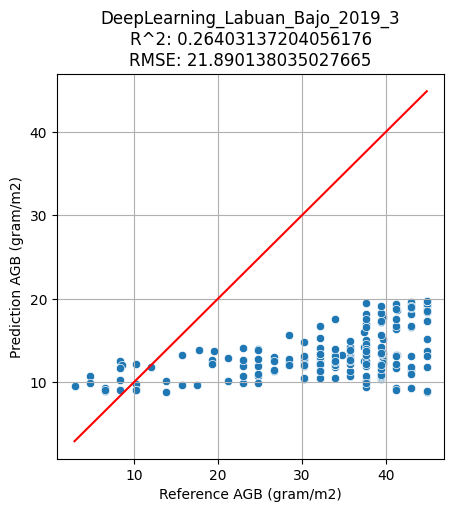

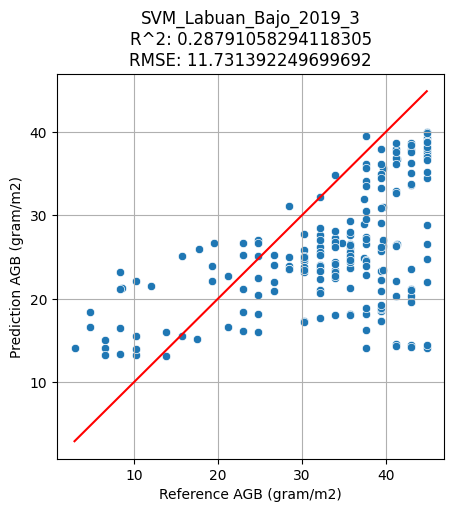

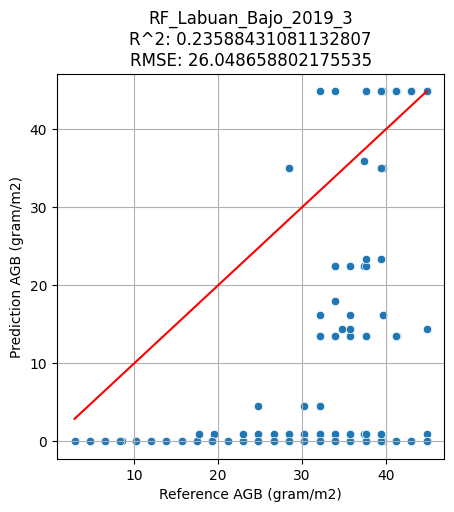

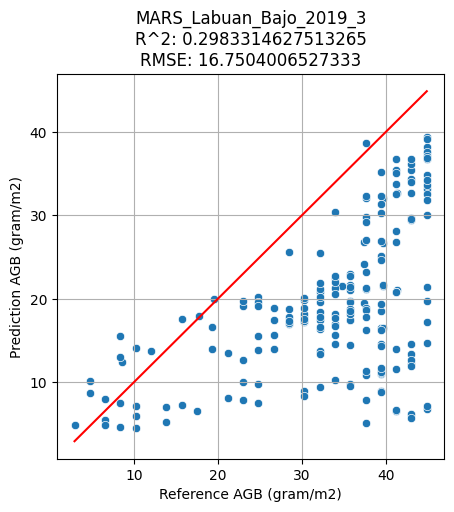

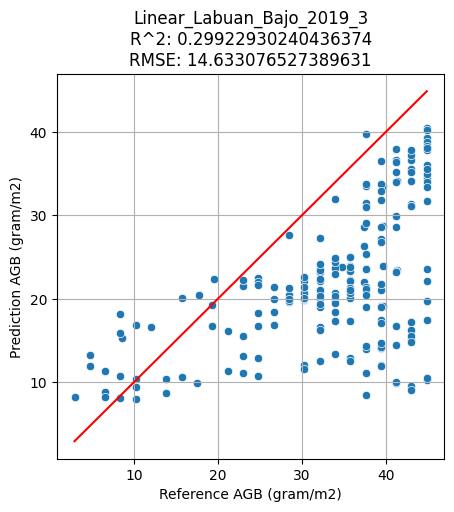

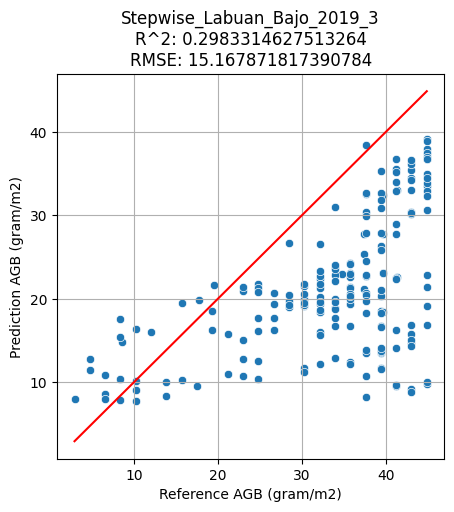

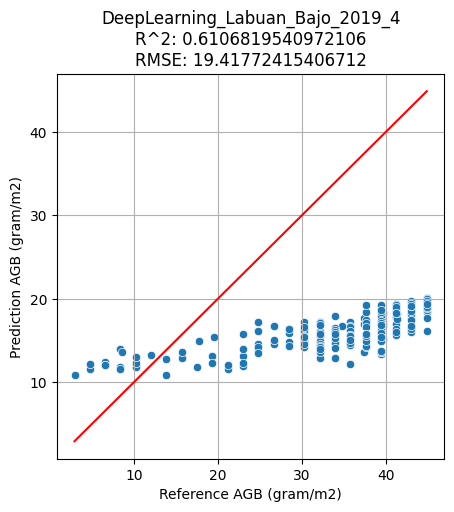

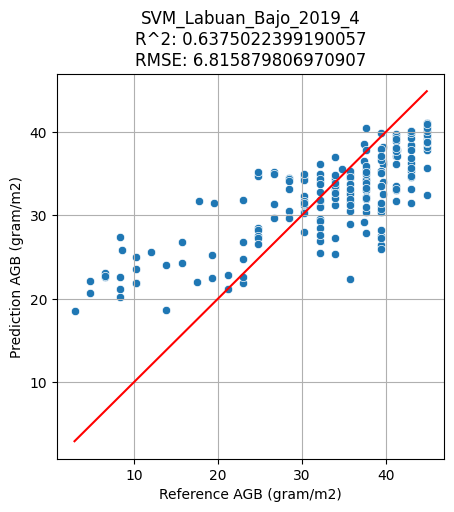

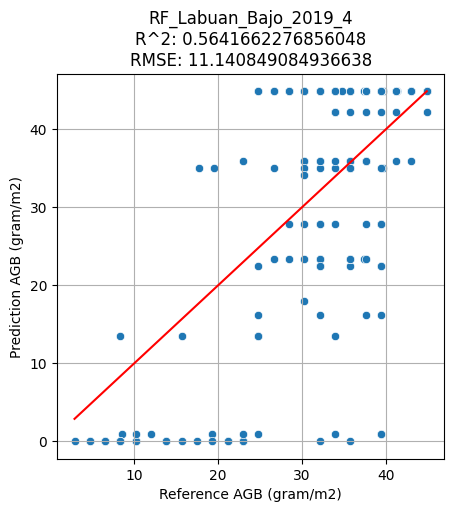

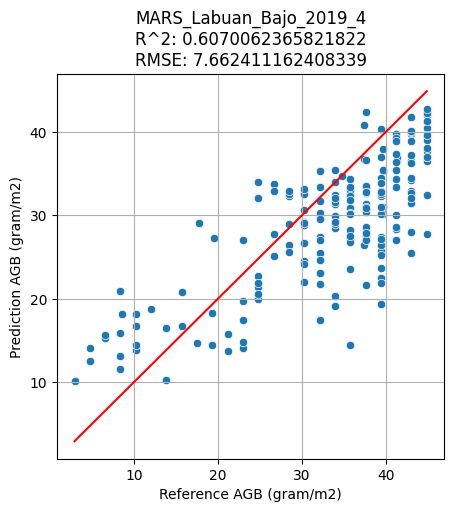

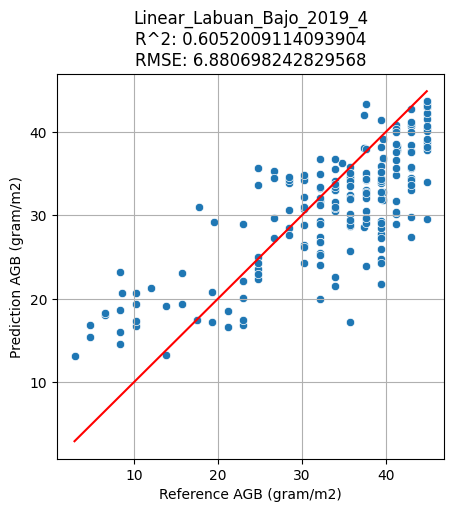

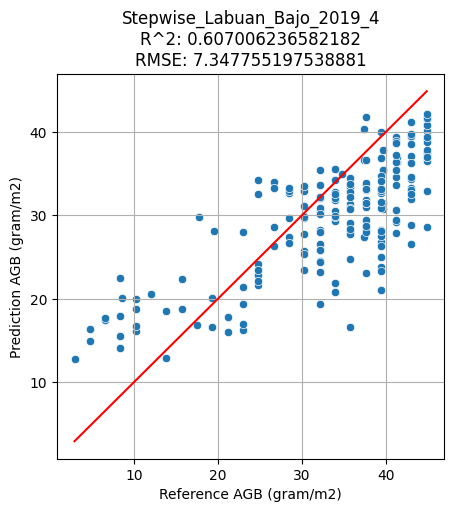

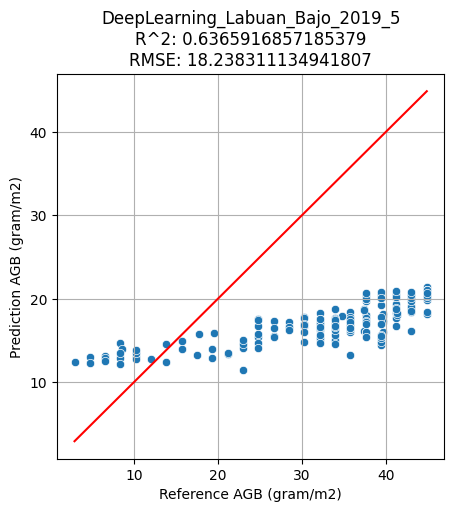

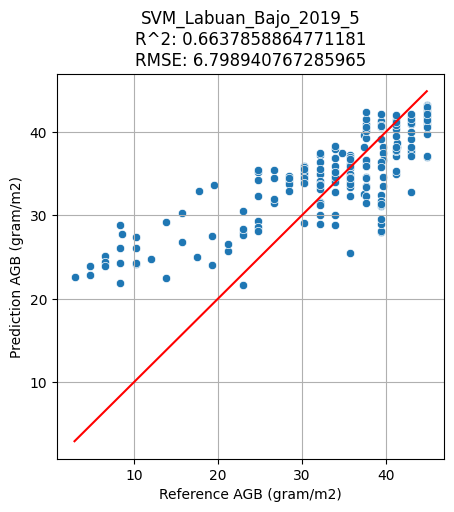

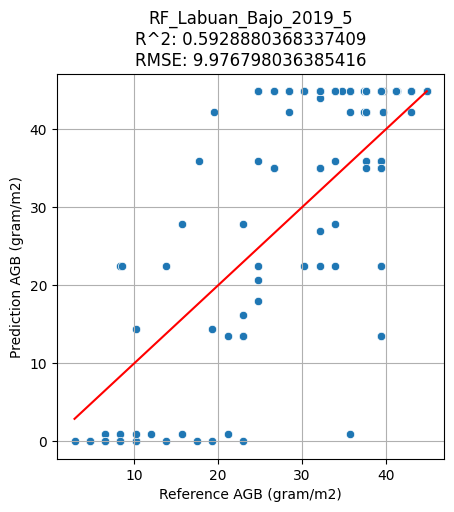

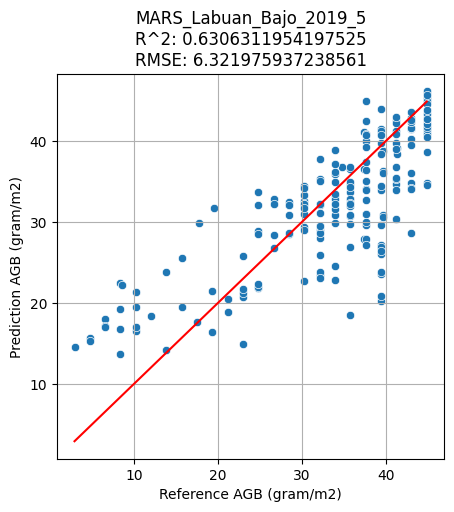

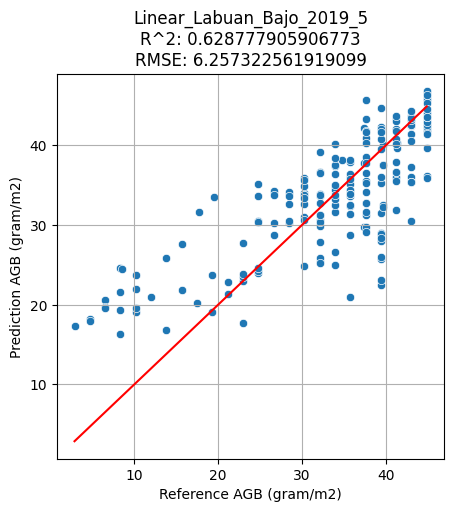

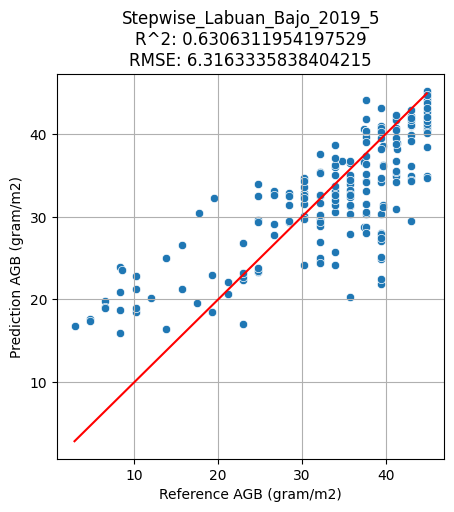

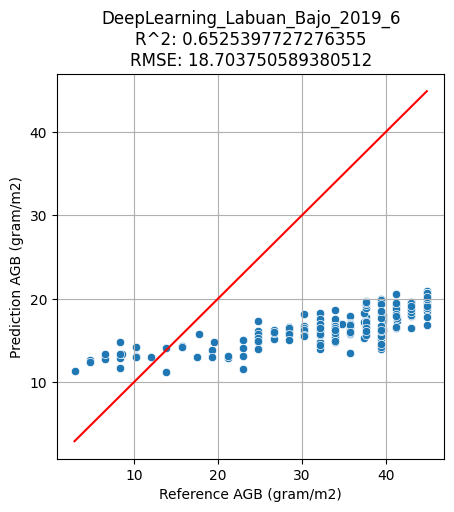

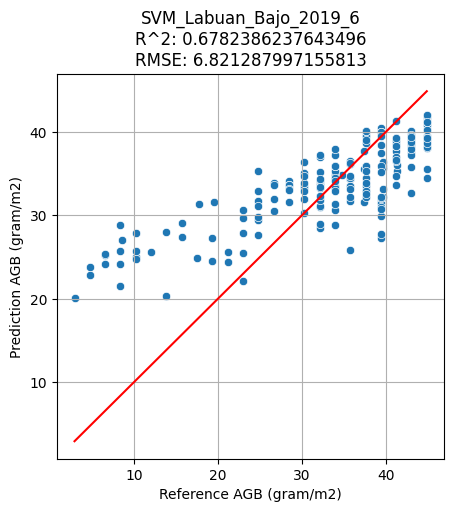

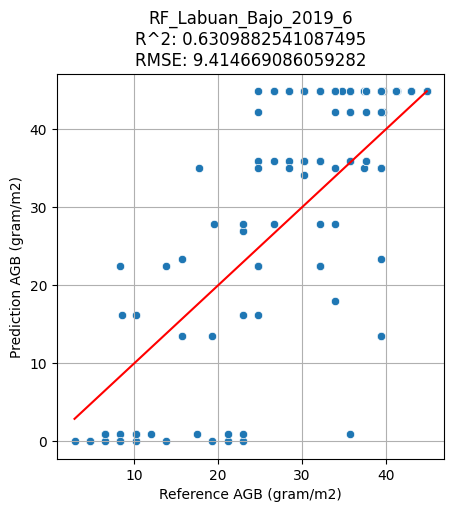

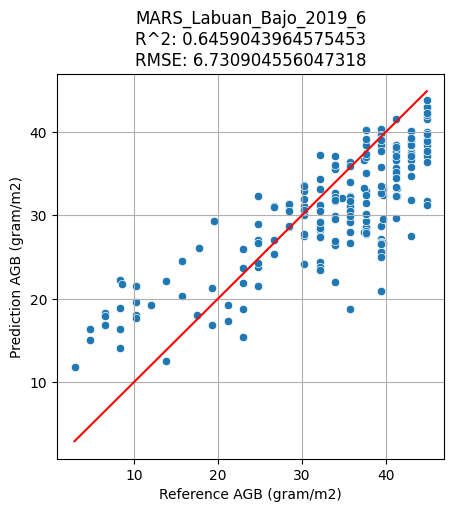

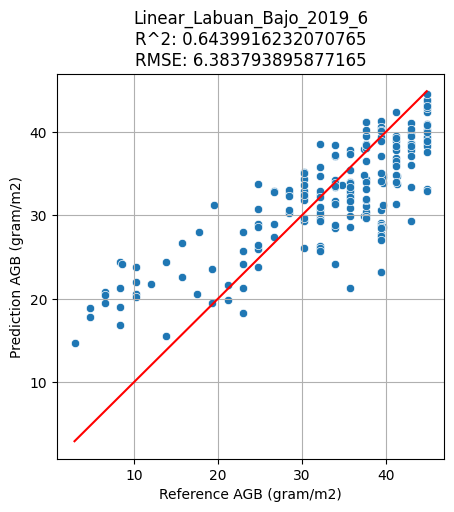

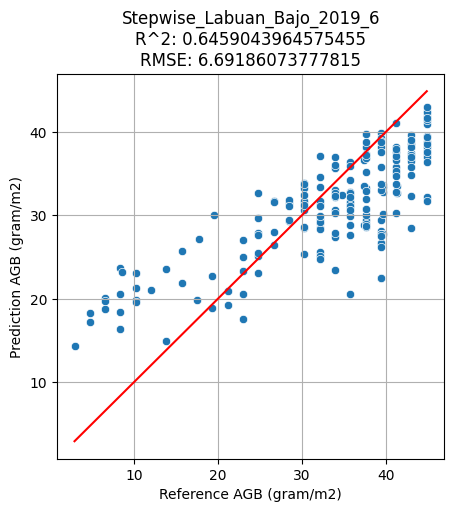

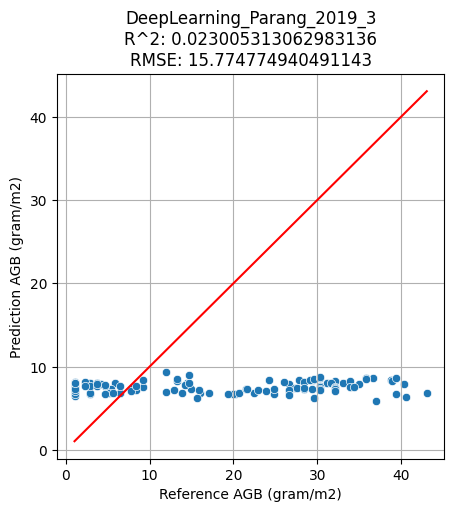

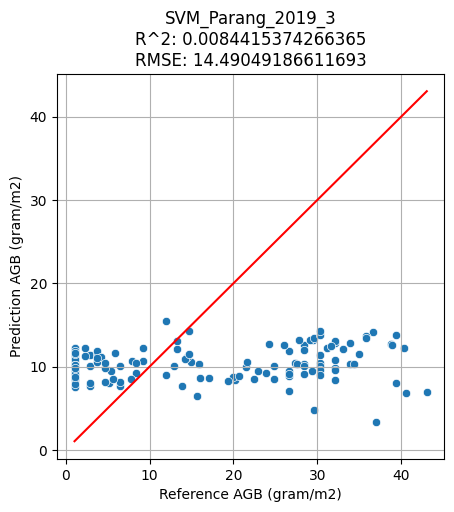

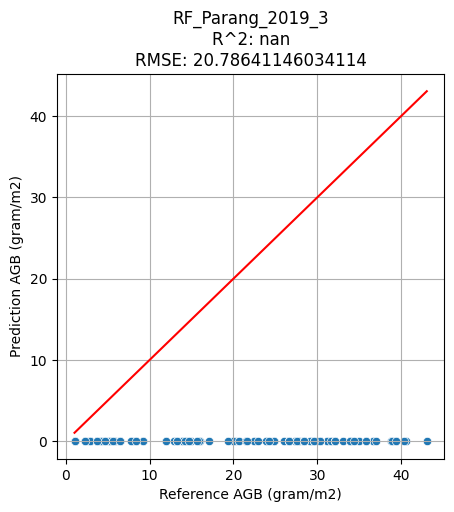

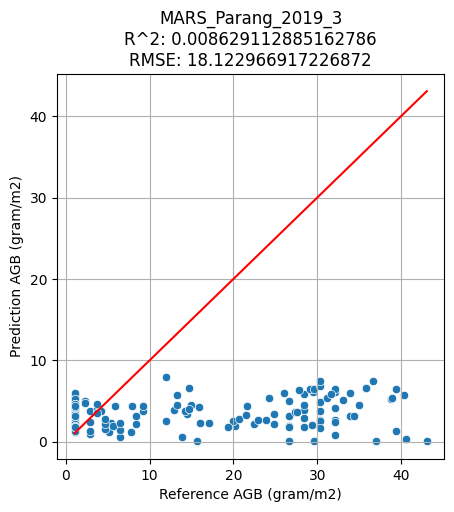

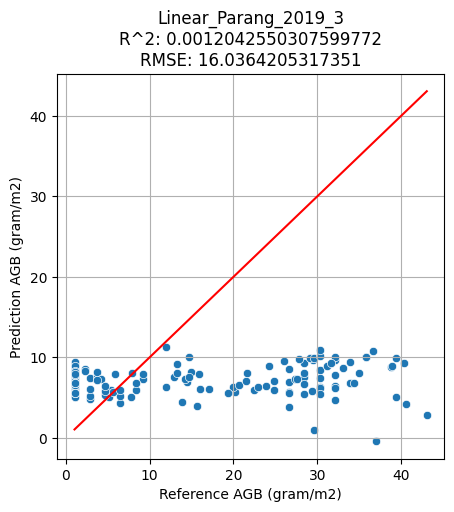

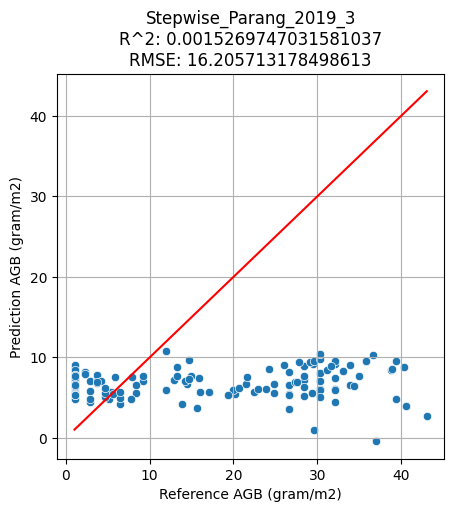

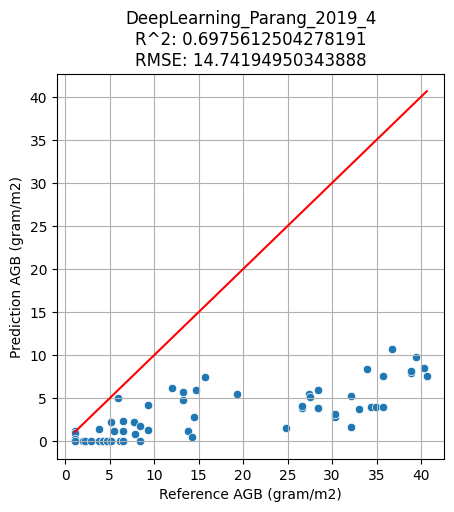

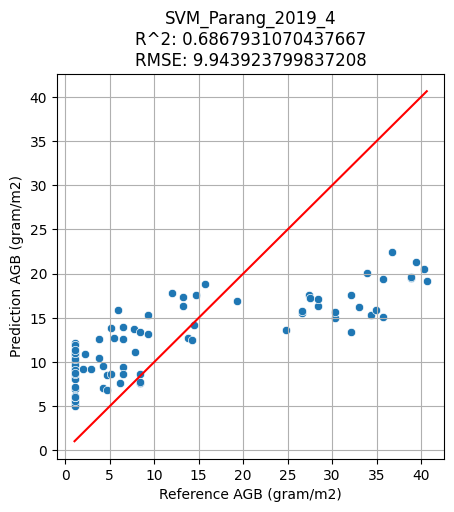

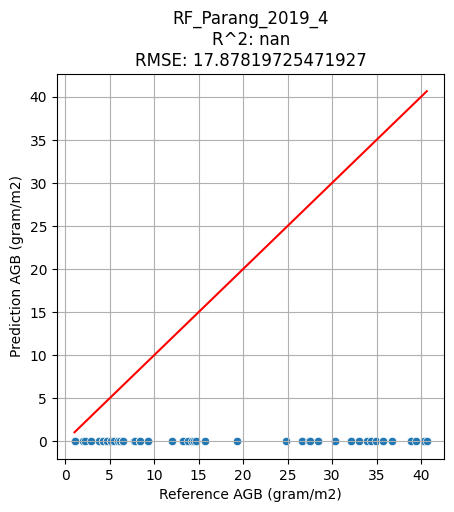

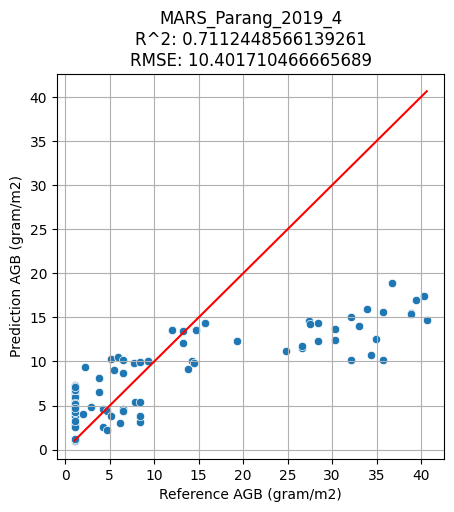

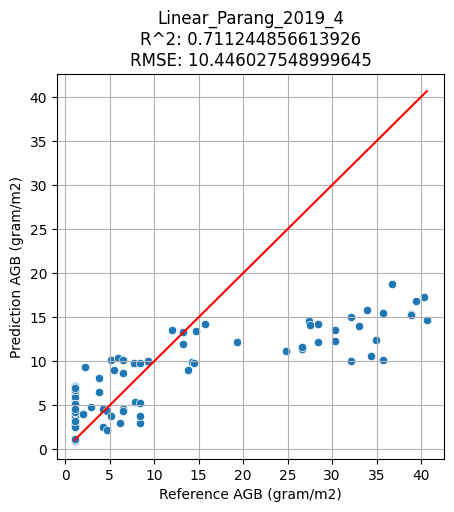

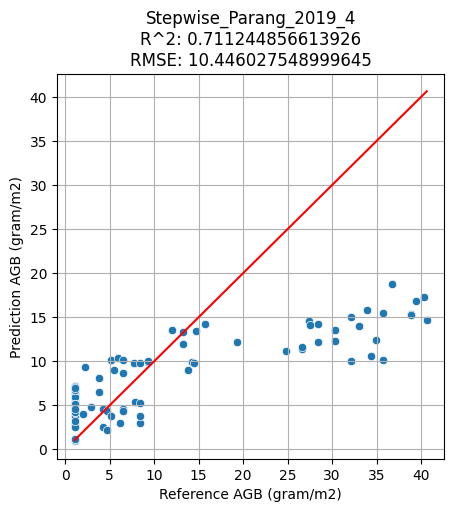

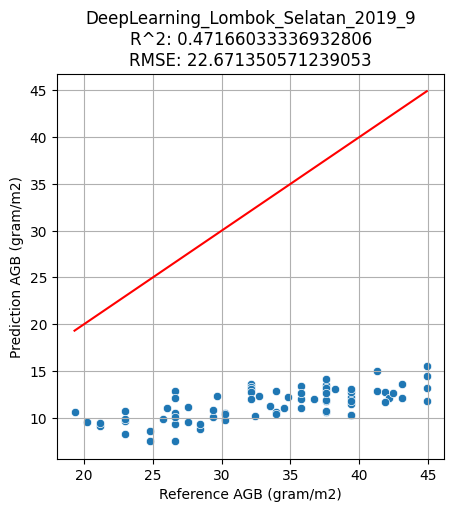

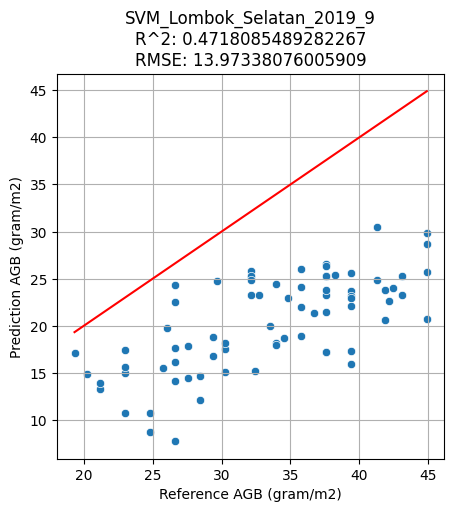

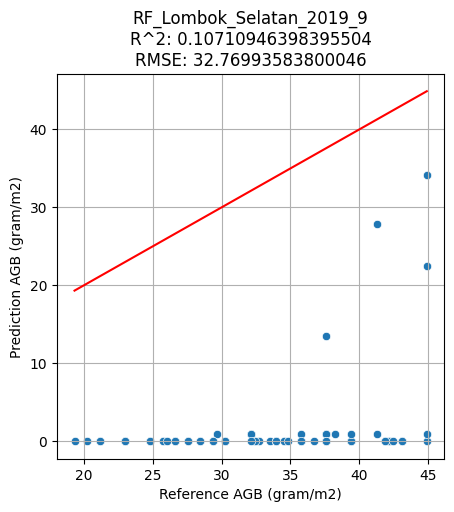

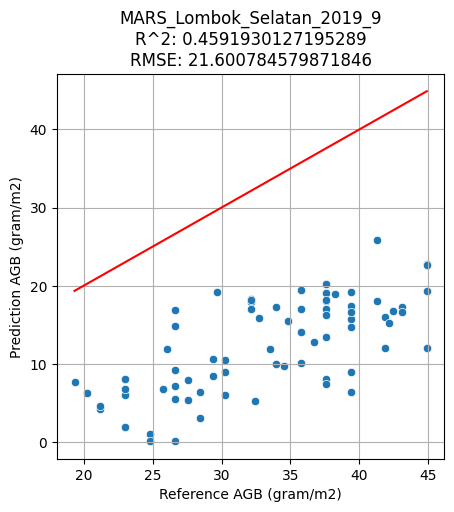

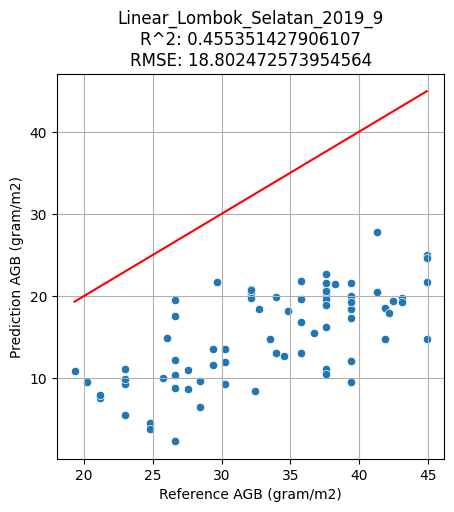

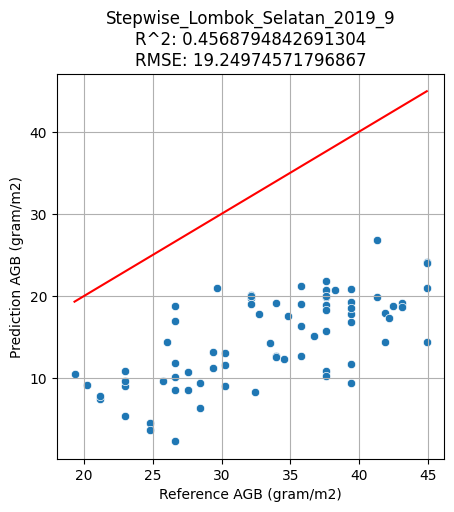

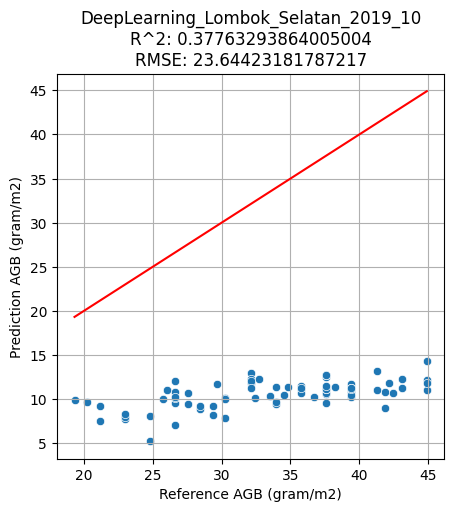

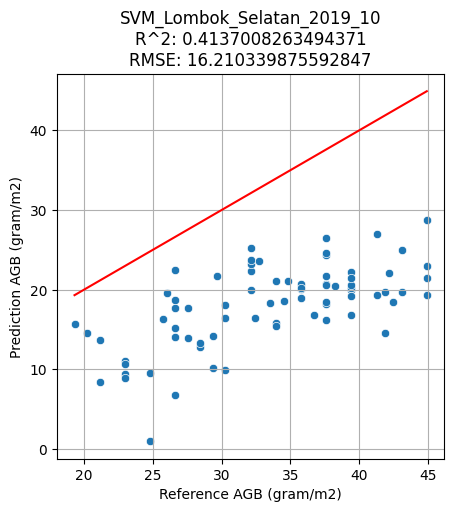

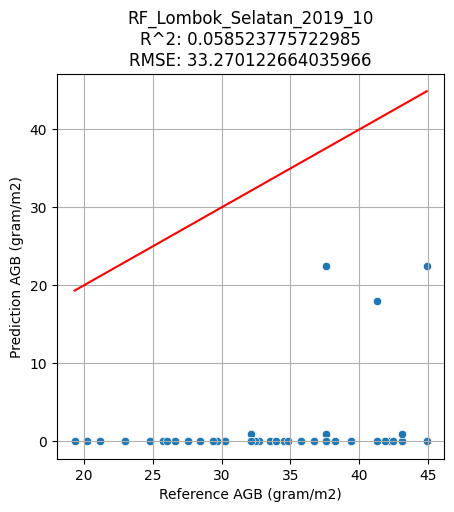

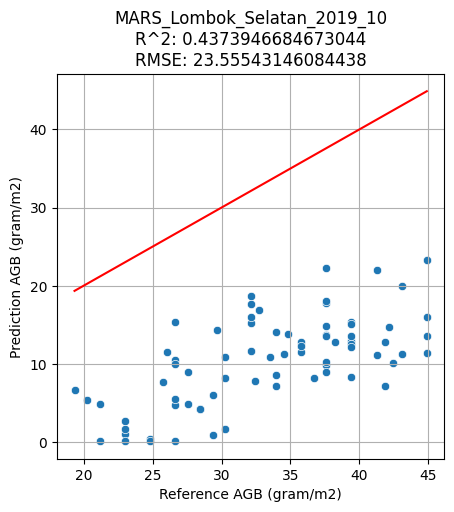

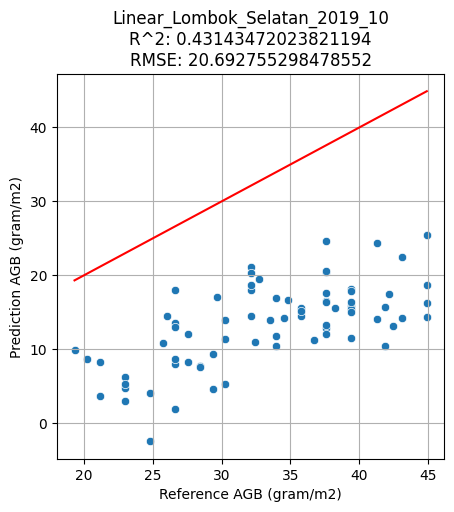

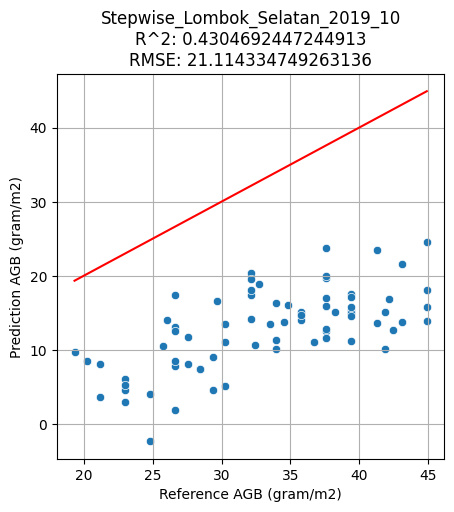

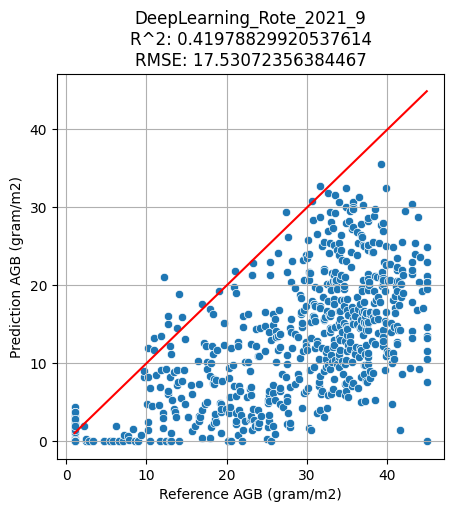

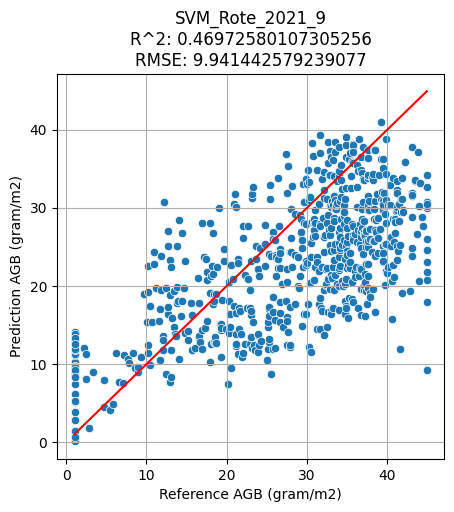

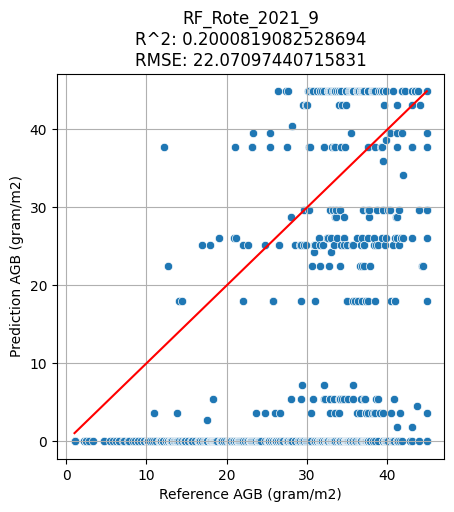

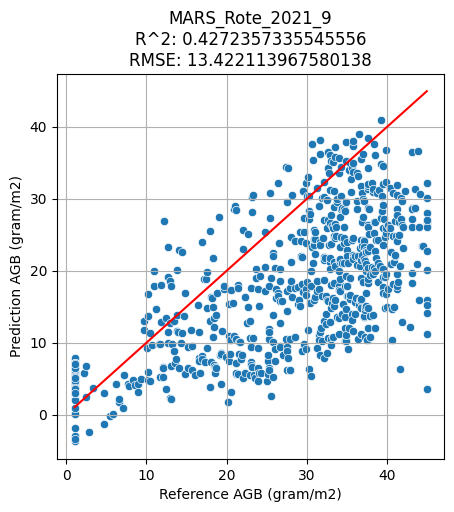

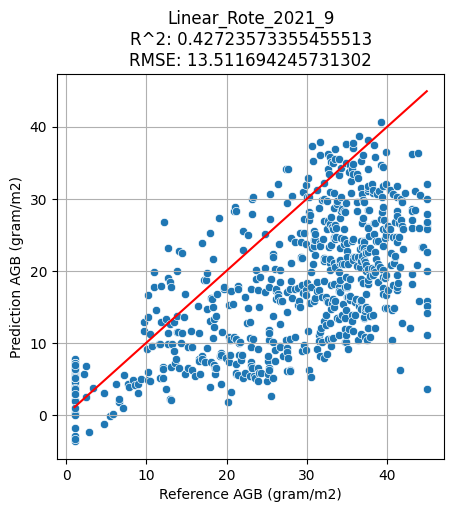

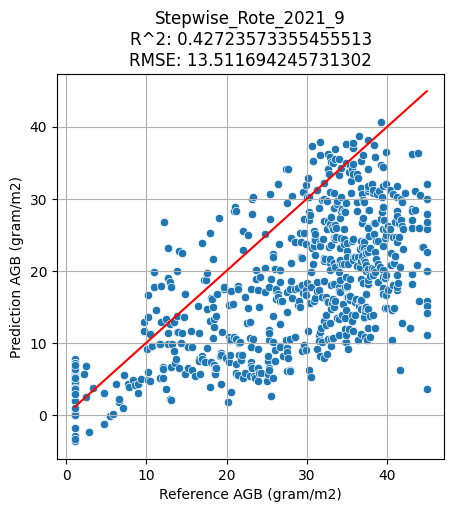

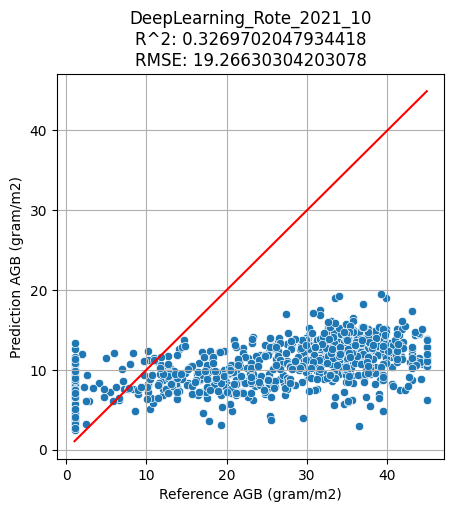

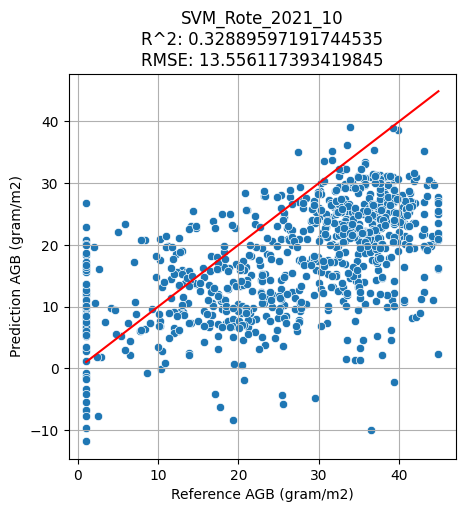

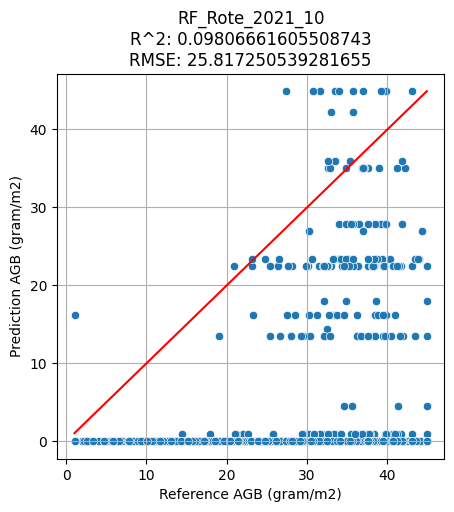

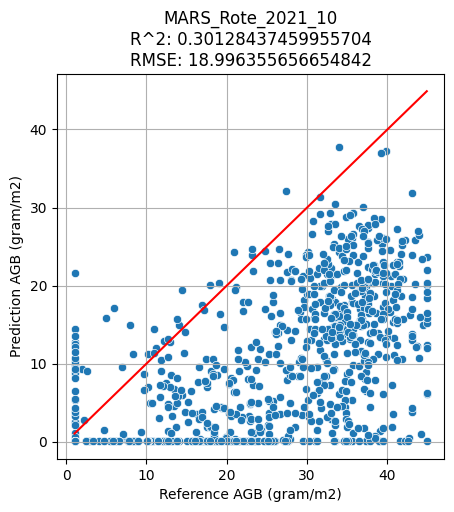

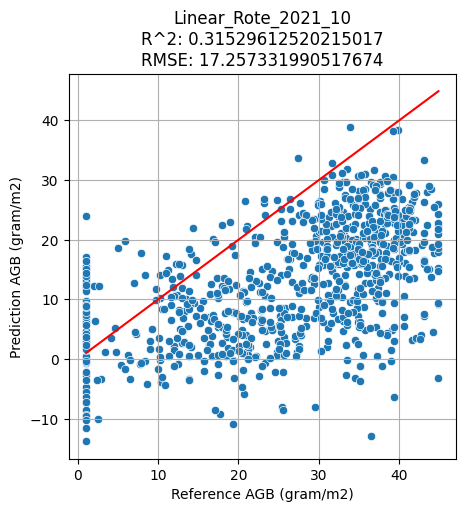

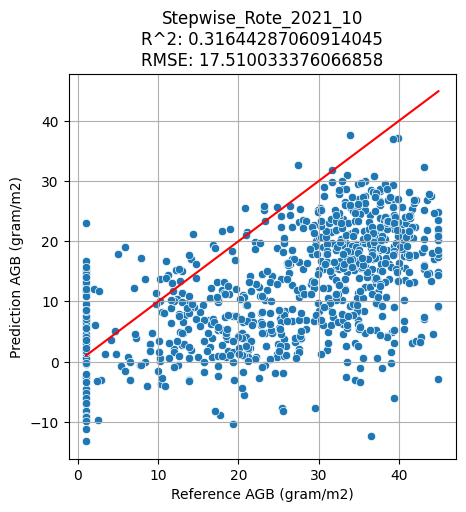

In [111]:
accuracy_assessment_folder = "AccuracyAssesment"

try:
    mkdir(accuracy_assessment_folder)
except Exception as e:
    print(e)


# Function to plot
def asses_plot(ref, predict, r2, rmse, name, region, year, month):
    plt.figure(figsize=(5, 5))
    plt.title(f"{name}_{region}_{year}_{month}\nR^2: {r2}\nRMSE: {rmse}")
    sns.scatterplot(x=ref, y=predict)
    plt.plot(
        [min(ref), max(ref)], [min(ref), max(ref)], linestyle="-", color="red"
    )  # 1:1 line
    plt.xlabel("Reference AGB (gram/m2)")
    plt.ylabel("Prediction AGB (gram/m2)")
    plt.title(f"{name}_{region}_{year}_{month}\nR^2: {r2}\nRMSE: {rmse}")
    plt.grid(True)
    plt.savefig(
        f"{accuracy_assessment_folder}/{name}_{region}_{year}_{month}",
        facecolor="white",
    )


# Combined data
main_arr = []

# Combined assessment
for x in TEST:
    for y in x["year"]:
        for z in x["month"]:
            region = x["region"]
            path = f"{LOG_PATH}{region}_{y}_{z}{SUFFIX}"

            if region == "Rote" and z == 9 and y == 2021:
                data = pd.read_excel(
                    "https://storage.googleapis.com/gee-ramiqcom-bucket/seagrass/sample/Rote.xlsx"
                )
                loaded = True
            elif region == "Parang" and z == 4 and y == 2019:
                data = pd.read_excel(
                    "https://storage.googleapis.com/gee-ramiqcom-bucket/seagrass/sample/Parang.xlsx"
                )
                loaded = True
            else:
                data = pd.read_csv(path)
                loaded = False
                logData = data[["logBLUE", "logGREEN"]]

            ref = data["reference" if loaded else "ref"]
            true_values = ref

            # Deep learning
            dl_result = data["deeplearning"] if loaded else deep_learning(logData)
            dl_r2 = np.corrcoef(ref, dl_result)[0, 1] ** 2
            dl_rmse = root_mean_squared_error(ref, dl_result)
            asses_plot(ref, dl_result, dl_r2, dl_rmse, "DeepLearning", region, y, z)

            # SVM
            svm_result = data["svm"] if loaded else svm_model.predict(logData)
            svm_r2 = np.corrcoef(ref, svm_result)[0, 1] ** 2
            svm_rmse = root_mean_squared_error(ref, svm_result)
            asses_plot(ref, svm_result, svm_r2, svm_rmse, "SVM", region, y, z)

            # RF
            rf_result = data["rf"] if loaded else rf.predict(logData)
            rf_r2 = np.corrcoef(ref, rf_result)[0, 1] ** 2
            rf_rmse = root_mean_squared_error(ref, rf_result)
            asses_plot(ref, rf_result, rf_r2, rf_rmse, "RF", region, y, z)

            # Mars
            mars_result = data["mars"] if loaded else mars.predict(logData)
            mars_r2 = np.corrcoef(ref, mars_result)[0, 1] ** 2
            mars_rmse = root_mean_squared_error(ref, mars_result)
            asses_plot(ref, mars_result, mars_r2, mars_rmse, "MARS", region, y, z)

            # Linear
            linear_result = data["stepwise"] if loaded else lr.predict(logData)
            linear_r2 = np.corrcoef(ref, linear_result)[0, 1] ** 2
            linear_rmse = root_mean_squared_error(ref, linear_result)
            asses_plot(
                ref, linear_result, linear_r2, linear_rmse, "Linear", region, y, z
            )

            # Stepwise
            stepwise_result = data["stepwise"] if loaded else stepwise(data["logGREEN"])
            stepwise_r2 = (
                np.corrcoef(ref, stepwise_result)[0, 1] ** 2
            )  # r2_score(ref, dl_result)
            stepwise_rmse = root_mean_squared_error(ref, stepwise_result)
            asses_plot(
                ref,
                stepwise_result,
                stepwise_r2,
                stepwise_rmse,
                "Stepwise",
                region,
                y,
                z,
            )

            # Data length
            data_length = len(true_values)

            # Region array
            arr_region = np.array([region] * data_length)
            arr_year = np.array([y] * data_length)
            arr_month = np.array([z] * data_length)

            # Stack
            stack = np.stack(
                (
                    arr_region.astype(str),
                    arr_year.astype(int),
                    arr_month.astype(int),
                    ref.astype(float),
                    stepwise_result.astype(float),
                    mars_result.astype(float),
                    svm_result.astype(float),
                    rf_result.astype(float),
                    dl_result.astype(float),
                ),
                axis=1,
            )
            main_arr.append(stack)

In [112]:
# Export to table
main_arr_stack = np.concatenate(main_arr)
main_df = pd.DataFrame(
    main_arr_stack,
    columns=[
        "region",
        "year",
        "month",
        "reference",
        "stepwise",
        "mars",
        "svm",
        "rf",
        "deeplearning",
    ],
)
main_df

,region,year,month,reference,stepwise,mars,svm,rf,deeplearning
0,Labuan_Bajo,2019,3,41.25,9.470262075425012,6.44145118509611,14.550150472099197,0.0,9.244929313659668
1,Labuan_Bajo,2019,3,39.42,11.68672621917085,8.908471443994774,17.29156415115792,0.0,10.315913200378418
2,Labuan_Bajo,2019,3,43.07,9.195489377345268,6.135617312408534,14.378942448830024,0.0,9.233504295349121
3,Labuan_Bajo,2019,3,39.42,11.594599472912137,8.80593039903902,17.299553568248278,0.0,10.358596801757812
4,Labuan_Bajo,2019,3,35.76,12.422863291348534,9.7278237784384,18.180668199792557,0.0,10.674432754516602
...,...,...,...,...,...,...,...,...,...
2682,Rote,2021,10,28.15,11.275333978207044,8.450574123311672,16.699279389684442,0.0,10.050896644592285
2683,Rote,2021,10,21.42,14.202690060289513,11.708847793059705,20.046642845551695,0.0,11.361827850341797
2684,Rote,2021,10,21.34,13.169467243355768,10.558826201903189,18.401709987802995,0.0,10.540769577026367
2685,Rote,2021,10,37.58,12.502730875768378,9.816719847138197,17.90381180707211,0.0,10.438682556152344


In [113]:
with pd.ExcelWriter(
    "accuracy_assessment_v4.xlsx",
    engine="xlsxwriter",
    engine_kwargs={"options": {"strings_to_numbers": True}},
) as writer:
    for x in TEST:
        for y in x.get("year"):
            for z in x.get("month"):
                region = x.get("region")
                data = main_df[
                    (main_df["region"] == region)
                    & (main_df["year"].astype(float) == y)
                    & (main_df["month"].astype(float) == z)
                ]
                print(data)

                # Export to table
                data.to_excel(writer, sheet_name=f"{region}_{y}_{z}", merge_cells=False)

          region  year month reference            stepwise  \
0    Labuan_Bajo  2019     3     41.25   9.470262075425012   
1    Labuan_Bajo  2019     3     39.42   11.68672621917085   
2    Labuan_Bajo  2019     3     43.07   9.195489377345268   
3    Labuan_Bajo  2019     3     39.42  11.594599472912137   
4    Labuan_Bajo  2019     3     35.76  12.422863291348534   
..           ...   ...   ...       ...                 ...   
199  Labuan_Bajo  2019     3     30.28  19.422739669756965   
200  Labuan_Bajo  2019     3     39.42  20.357050777445636   
201  Labuan_Bajo  2019     3     39.42  21.043959069115402   
202  Labuan_Bajo  2019     3     37.59   22.72250997444803   
203  Labuan_Bajo  2019     3     37.59  22.774735960619807   

                   mars                 svm                  rf  \
0      6.44145118509611  14.550150472099197                 0.0   
1     8.908471443994774   17.29156415115792                 0.0   
2     6.135617312408534  14.378942448830024           

# Accuracy Assessment Bimonthly


In [81]:
# Function to plot
def asses_plot(ref, predict, r2, rmse, name, region, year, month):
    print(f"{name}_{region}_{year}_{month}\nR^2: {r2}\nRMSE: {rmse}")

    # plt.figure(figsize=(5, 5))
    # sns.scatterplot(x=ref, y=predict)
    # plt.plot([min(ref), max(ref)], [min(ref), max(ref)], linestyle='-', color='red')  # 1:1 line
    # plt.xlabel("Reference")
    # plt.ylabel("Prediction")
    # plt.title("True vs. Predicted AGB (gram/m2)")
    # plt.grid(True)
    # plt.show()


# Combined data
main_arr_bimonthly = []

# Combined assessment
for x in TEST:
    for y in x["year"]:
        dl_arr = []
        svm_arr = []
        mars_arr = []
        stepwise_arr = []
        rf_arr = []

        for z in x["month"]:
            region = x["region"]
            path = f"{LOG_PATH}{region}_{y}_{z}{SUFFIX}"

            data = pd.read_csv(path)
            ref = data["ref"].to_numpy()
            logData = data[["logBLUE", "logGREEN"]].to_numpy()
            true_values = ref

            # Deep learning
            dl_result = deep_learning(logData)
            dl_arr.append(dl_result)

            # SVM
            svm_result = svm_model.predict(logData)
            svm_arr.append(svm_result)

            # Mars
            mars_result = mars.predict(logData)
            mars_arr.append(mars_result)

            # Stepwise
            stepwise_result = stepwise(data["logGREEN"])
            stepwise_arr.append(stepwise_result)

            # RF
            rf_result = rf.predict(logData)
            rf_arr.append(rf_result)

        dl_result = np.mean(dl_arr, axis=0)
        svm_result = np.mean(svm_arr, axis=0)
        mars_result = np.mean(mars_arr, axis=0)
        stepwise_result = np.mean(stepwise_arr, axis=0)
        rf_result = np.mean(rf_arr, axis=0)

        dl_r2 = r2_score(ref, dl_result)
        dl_rmse = root_mean_squared_error(ref, dl_result)
        # asses_plot(ref, dl_result, dl_r2, dl_rmse, 'DeepLearning', region, y, z)

        svm_r2 = r2_score(ref, svm_result)
        svm_rmse = root_mean_squared_error(ref, svm_result)
        # asses_plot(ref, svm_result, svm_r2, svm_rmse, 'SVM', region, y, z)

        mars_r2 = r2_score(ref, mars_result)
        mars_rmse = root_mean_squared_error(ref, mars_result)
        # asses_plot(ref, mars_result, mars_r2, mars_rmse, 'MARS', region, y, z)

        stepwise_r2 = r2_score(ref, stepwise_result)
        stepwise_rmse = root_mean_squared_error(ref, stepwise_result)
        # asses_plot(ref, stepwise_result, stepwise_r2, stepwise_rmse, 'Stepwise', region, y, z)

        # Data length
        data_length = len(true_values)

        # Region array
        arr_region = [region] * data_length
        arr_year = [y] * data_length
        arr_month = [z] * data_length

        # Stack
        stack = np.stack(
            (
                arr_region,
                arr_year,
                arr_month,
                ref,
                stepwise_result,
                mars_result,
                svm_result,
                dl_result,
                rf_result,
            ),
            axis=1,
        )
        main_arr.append(stack)

main_arr_stack_bimonth = np.concatenate(main_arr)
main_df_bimonth = pd.DataFrame(
    main_arr_stack,
    columns=[
        "region",
        "year",
        "month",
        "reference",
        "stepwise",
        "mars",
        "svm",
        "deeplearning",
        "rf",
    ],
)
main_df_bimonth.to_excel("accuracy_assessment_v3_bimonth.xlsx", merge_cells=False)
main_df_bimonth

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (2,) + inhomogeneous part.

# Apply to sample data time series


In [84]:
# Load sample data to see pattern
sample_data = pd.read_csv(SAMPLE_PATH)
sample_data

,logBLUE,logGREEN,month,year,region
0,6.335252,6.344790,1.0,2019.0,Banda_Neira
1,6.508546,6.533214,1.0,2019.0,Banda_Neira
2,6.506759,6.644117,1.0,2019.0,Banda_Neira
3,6.552169,6.657994,1.0,2019.0,Banda_Neira
4,6.527980,6.676947,1.0,2019.0,Banda_Neira
...,...,...,...,...,...
62326482,6.689627,6.870326,12.0,2021.0,Ujung_Kulon
62326483,6.824346,6.969623,12.0,2021.0,Ujung_Kulon
62326484,6.763107,6.910688,12.0,2021.0,Ujung_Kulon
62326485,6.720981,6.877680,12.0,2021.0,Ujung_Kulon


In [85]:
# Regress data
input_data = sample_data[["logBLUE", "logGREEN"]].to_numpy()
svm_prediction = svm_model.predict(input_data)
mars_prediction = mars.predict(input_data)
stepwise_prediction = stepwise(sample_data["logGREEN"])
deeplearning_prediction = deep_learning(input_data)
rf_prediction = rf.predict(input_data)

1522/1522 ━━━━━━━━━━━━━━━━━━━━ 1s 802us/step


In [86]:
# Add predicted data back to the datafram
sample_data["SVM"] = svm_prediction.tolist()
sample_data["MARS"] = mars_prediction.tolist()
sample_data["stepwise"] = stepwise_prediction.tolist()
sample_data["deep_learning"] = deeplearning_prediction.tolist()
sample_data["rf"] = rf_prediction.tolist()
sample_data

,logBLUE,logGREEN,month,year,region,SVM,MARS,stepwise,deep_learning,rf
0,6.335252,6.344790,1.0,2019.0,Banda_Neira,22.487230,17.793478,19.669352,11.551168,1.796
1,6.508546,6.533214,1.0,2019.0,Banda_Neira,18.906239,13.308950,15.640282,10.559400,0.000
2,6.506759,6.644117,1.0,2019.0,Banda_Neira,18.071810,10.669448,13.268854,10.886952,0.000
3,6.552169,6.657994,1.0,2019.0,Banda_Neira,17.373272,10.339154,12.972105,10.527251,0.000
4,6.527980,6.676947,1.0,2019.0,Banda_Neira,17.533425,9.888083,12.566846,10.792947,0.000
...,...,...,...,...,...,...,...,...,...,...
62326482,6.689627,6.870326,12.0,2021.0,Ujung_Kulon,13.778363,5.285611,8.431812,9.917377,0.000
62326483,6.824346,6.969623,12.0,2021.0,Ujung_Kulon,11.055475,2.922334,6.308554,9.013681,0.000
62326484,6.763107,6.910688,12.0,2021.0,Ujung_Kulon,12.427323,4.325006,7.568768,9.385671,0.000
62326485,6.720981,6.877680,12.0,2021.0,Ujung_Kulon,13.291669,5.110589,8.274566,9.662745,0.000


In [87]:
# Only select some column
sample_prediction = sample_data[
    ["region", "year", "month", "SVM", "MARS", "stepwise", "deep_learning", "rf"]
]

# Save data
sample_monthly = sample_prediction.groupby(["region", "year", "month"]).agg("mean")
sample_monthly.to_excel(
    "prediction_agb_seagrass_monthly_yearly_region_v3.xlsx", merge_cells=False
)

In [88]:
# Set the month to 2 months
for x in range(1, 13, 2):
    sample_prediction.loc[sample_prediction["month"] == x, "month"] = x + 1
    sample_prediction.loc[sample_prediction["month"] == x + 1, "month"] = (x + 1) / 2

sample_prediction.sort_values(by=["month"])

,region,year,month,SVM,MARS,stepwise,deep_learning,rf
0,Banda_Neira,2019.0,1.0,22.487230,17.793478,19.669352,11.551168,1.796
28579803,Derawan,2020.0,1.0,10.021169,0.386169,4.029968,9.279429,0.000
28579804,Derawan,2020.0,1.0,12.333148,2.271126,5.723484,10.080546,0.000
28579805,Derawan,2020.0,1.0,11.942839,1.952327,5.437063,9.941925,0.000
28579806,Derawan,2020.0,1.0,12.042434,2.155847,5.619913,9.930348,0.000
...,...,...,...,...,...,...,...,...
35931810,Gorontalo,2021.0,6.0,30.550533,24.390574,25.596432,15.623570,38.614
35931811,Gorontalo,2021.0,6.0,30.763226,24.092991,25.329072,15.941811,38.614
35931812,Gorontalo,2021.0,6.0,30.116564,23.896680,25.152699,15.423674,30.532
35931799,Gorontalo,2021.0,6.0,33.517161,28.727407,29.492806,16.707266,44.002


In [89]:
# Save data
sample_bimonthly = sample_prediction.groupby(["region", "year", "month"]).agg("mean")
sample_bimonthly.to_excel(
    "prediction_agb_seagrass_bimonthly_yearly_region_v3.xlsx", merge_cells=False
)

             region    year  month        SVM       MARS   stepwise  \
0       Banda_Neira  2019.0    1.0  22.487230  17.793478  19.669352   
1       Banda_Neira  2019.0    1.0  18.906239  13.308950  15.640282   
2       Banda_Neira  2019.0    1.0  18.071810  10.669448  13.268854   
3       Banda_Neira  2019.0    1.0  17.373272  10.339154  12.972105   
4       Banda_Neira  2019.0    1.0  17.533425   9.888083  12.566846   
...             ...     ...    ...        ...        ...        ...   
703856  Banda_Neira  2021.0    6.0  14.196825   5.938978   9.018822   
703857  Banda_Neira  2021.0    6.0  13.074354   5.476731   8.603521   
703858  Banda_Neira  2021.0    6.0  12.190395   4.451735   7.682626   
703859  Banda_Neira  2021.0    6.0  10.770429   3.349018   6.691903   
703860  Banda_Neira  2021.0    6.0  10.256778   2.698843   6.107762   

        deep_learning     rf  
0           11.551168  1.796  
1           10.559400  0.000  
2           10.886952  0.000  
3           10.527251  

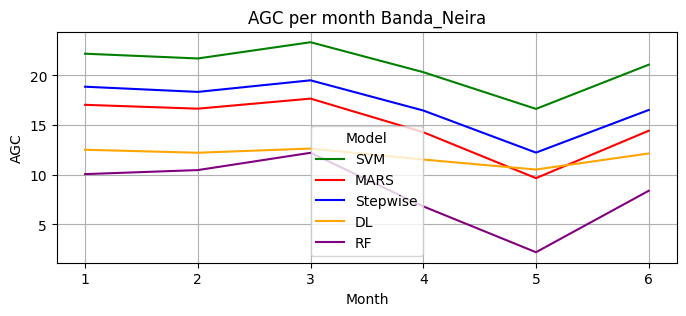

            region    year  month        SVM       MARS   stepwise  \
703861    Belitung  2019.0    1.0  26.394448  21.809459  23.277461   
703862    Belitung  2019.0    1.0  26.480632  22.783184  24.152292   
703863    Belitung  2019.0    1.0  26.829534  22.413277  23.819954   
703864    Belitung  2019.0    1.0  27.640063  23.317421  24.632271   
703865    Belitung  2019.0    1.0  27.173937  22.628346  24.013179   
...            ...     ...    ...        ...        ...        ...   
10706234  Belitung  2021.0    6.0  23.084676  17.174243  19.113007   
10706235  Belitung  2021.0    6.0  18.480125  12.256434  14.694662   
10706236  Belitung  2021.0    6.0  17.400607  11.098455  13.654290   
10706237  Belitung  2021.0    6.0  16.624117  10.540440  13.152949   
10706238  Belitung  2021.0    6.0  13.130370   7.739547  10.636520   

          deep_learning      rf  
703861        13.089720  22.450  
703862        12.834128  23.348  
703863        13.221460  23.348  
703864        13.548399

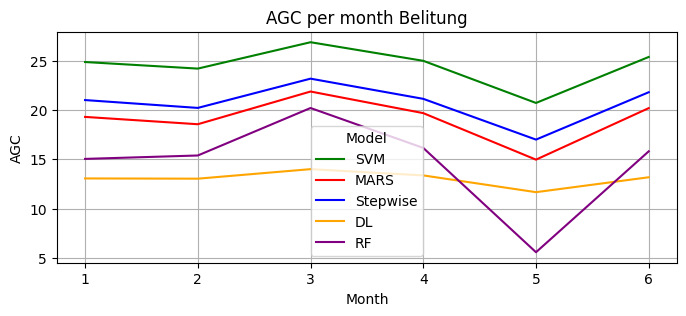

         region    year  month        SVM       MARS   stepwise  \
10706239   Biak  2019.0    1.0  20.258500  16.216433  18.252475   
10706240   Biak  2019.0    1.0  15.913762  12.575237  14.981087   
10706241   Biak  2019.0    1.0  15.601673  11.098455  13.654290   
10706242   Biak  2019.0    1.0  33.334907  30.557923  31.137411   
10706243   Biak  2019.0    1.0  14.427845   8.501006  11.320644   
...         ...     ...    ...        ...        ...        ...   
25196936   Biak  2021.0    6.0   1.993872   0.057334  -0.111666   
25196937   Biak  2021.0    6.0   4.688220   0.057334   2.143178   
25196938   Biak  2021.0    6.0   5.742280   0.057334   3.014253   
25196939   Biak  2021.0    6.0   4.899741   0.057334   2.027216   
25196940   Biak  2021.0    6.0   4.958792   0.057334   2.544415   

          deep_learning      rf  
10706239      10.535104   0.000  
10706240       8.894922   0.000  
10706241       9.146382   0.000  
10706242      15.846175  42.206  
10706243       9.236984  

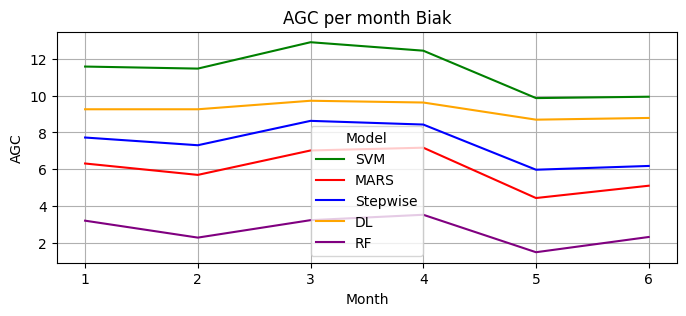

           region    year  month        SVM        MARS    stepwise  \
25196941  Bunaken  2019.0    1.0  19.511618   38.328991   38.119232   
25196942  Bunaken  2019.0    1.0  15.699212   34.556442   34.729831   
25196943  Bunaken  2019.0    1.0  61.072523  114.485710  106.541304   
25196944  Bunaken  2019.0    1.0  63.673447  180.470165  165.824229   
25196945  Bunaken  2019.0    1.0  63.673447  180.470165  165.824229   
...           ...     ...    ...        ...         ...         ...   
28240302  Bunaken  2021.0    6.0  38.032554   44.556887   43.714609   
28240303  Bunaken  2021.0    6.0  37.542970   47.469615   46.331514   
28240304  Bunaken  2021.0    6.0  38.120440   45.761573   44.796944   
28240305  Bunaken  2021.0    6.0  39.291964   47.736797   46.571559   
28240306  Bunaken  2021.0    6.0  37.952964   45.844109   44.871098   

          deep_learning      rf  
25196941      55.549896  44.900  
25196942      56.104717  44.900  
25196943      30.913080  44.900  
25196944   

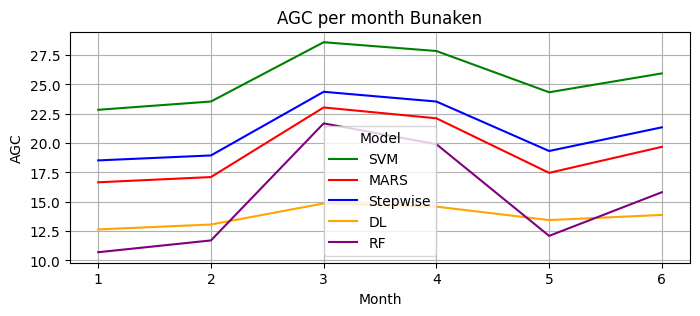

           region    year  month        SVM       MARS   stepwise  \
28240307  Derawan  2019.0    1.0  12.197714   6.135617   9.195489   
28240308  Derawan  2019.0    1.0  13.057709   7.224255  10.173563   
28240309  Derawan  2019.0    1.0  11.171125   5.447224   8.577011   
28240310  Derawan  2019.0    1.0  13.650347   7.480464  10.403751   
28240311  Derawan  2019.0    1.0  17.496996  11.747536  14.237449   
...           ...     ...    ...        ...        ...        ...   
29152929  Derawan  2021.0    6.0  10.104730   1.290793   4.842716   
29152930  Derawan  2021.0    6.0  10.997251   2.028435   5.505442   
29152931  Derawan  2021.0    6.0  12.239101   3.241601   6.595396   
29152932  Derawan  2021.0    6.0  13.898486   5.154220   8.313765   
29152933  Derawan  2021.0    6.0  13.619552   5.096064   8.261516   

          deep_learning   rf  
28240307       8.634014  0.0  
28240308       8.805134  0.0  
28240309       8.241679  0.0  
28240310       9.085545  0.0  
28240311      10

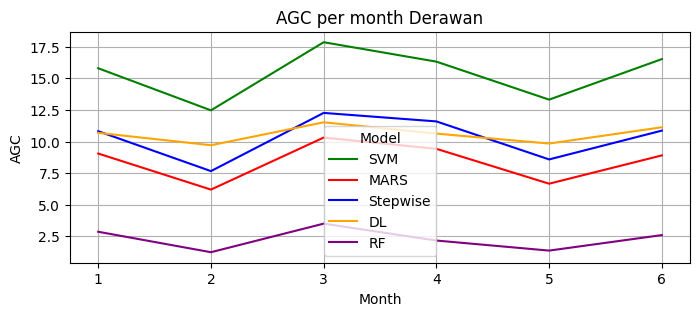

             region    year  month        SVM       MARS   stepwise  \
29152934  Gorontalo  2019.0    1.0  20.895499  14.130836  16.378696   
29152935  Gorontalo  2019.0    1.0  22.251037  16.169560  18.210362   
29152936  Gorontalo  2019.0    1.0  20.747862  14.023829  16.282557   
29152937  Gorontalo  2019.0    1.0  26.466319  20.280818  21.904071   
29152938  Gorontalo  2019.0    1.0  24.950076  17.919321  19.782414   
...             ...     ...    ...        ...        ...        ...   
36005264  Gorontalo  2021.0    6.0  25.767154  18.122092  19.964591   
36005265  Gorontalo  2021.0    6.0  24.320060  16.642586  18.635347   
36005266  Gorontalo  2021.0    6.0  25.016455  19.404014  21.116318   
36005267  Gorontalo  2021.0    6.0  24.759623  19.323475  21.043959   
36005268  Gorontalo  2021.0    6.0  24.744189  19.030518  20.780755   

          deep_learning      rf  
29152934      11.653705   0.000  
29152935      11.922570   0.000  
29152936      11.585734   0.000  
29152937   

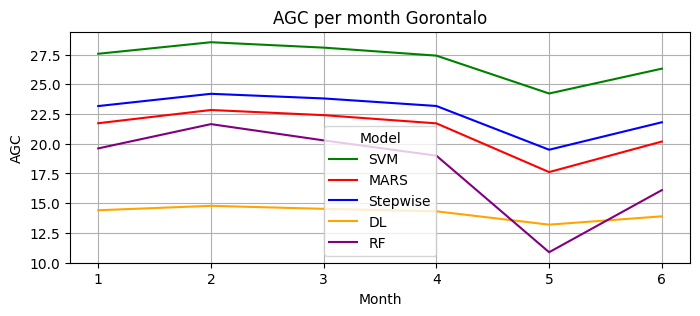

          region    year  month        SVM       MARS   stepwise  \
36005269  Kapota  2019.0    1.0  12.663660   3.633399   6.947402   
36005270  Kapota  2019.0    1.0  12.320753   4.240907   7.493210   
36005271  Kapota  2019.0    1.0  11.066767   2.232635   5.688903   
36005272  Kapota  2019.0    1.0   9.442581   0.552339   4.179261   
36005273  Kapota  2019.0    1.0   8.064032   0.057334   3.299362   
...          ...     ...    ...        ...        ...        ...   
43732745  Kapota  2021.0    6.0  21.160356  15.206393  17.345017   
43732746  Kapota  2021.0    6.0  20.516737  14.238338  16.475280   
43732747  Kapota  2021.0    6.0  26.061403  21.660906  23.143995   
43732748  Kapota  2021.0    6.0  26.318708  21.279024  22.800898   
43732749  Kapota  2021.0    6.0  25.679141  20.086188  21.729209   

          deep_learning      rf  
36005269       9.787028   0.000  
36005270       9.347480   0.000  
36005271       9.266817   0.000  
36005272       8.852242   0.000  
36005273     

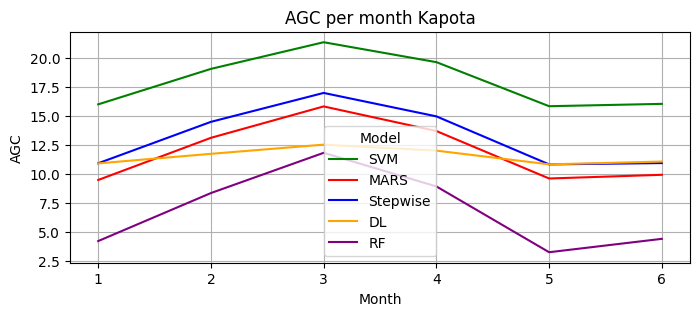

               region    year  month        SVM       MARS   stepwise  \
43732750  Labuan_Bajo  2019.0    1.0  19.122763  13.020859  15.381450   
43732751  Labuan_Bajo  2019.0    1.0  18.919680  12.939198  15.308084   
43732752  Labuan_Bajo  2019.0    1.0  17.355949  11.098455  13.654290   
43732753  Labuan_Bajo  2019.0    1.0  17.967852  11.211687  13.756022   
43732754  Labuan_Bajo  2019.0    1.0  19.091098  12.736294  15.125787   
...               ...     ...    ...        ...        ...        ...   
45169102  Labuan_Bajo  2021.0    6.0  15.215861   7.416145  10.345964   
45169103  Labuan_Bajo  2021.0    6.0  14.676986   7.113052  10.073653   
45169104  Labuan_Bajo  2021.0    6.0  16.184957   8.249938  11.095075   
45169105  Labuan_Bajo  2021.0    6.0  20.159127  12.575237  14.981087   
45169106  Labuan_Bajo  2021.0    6.0  23.475296  16.029503  18.084530   

          deep_learning   rf  
43732750      10.799591  0.0  
43732751      10.689702  0.0  
43732752      10.259583  0.0  

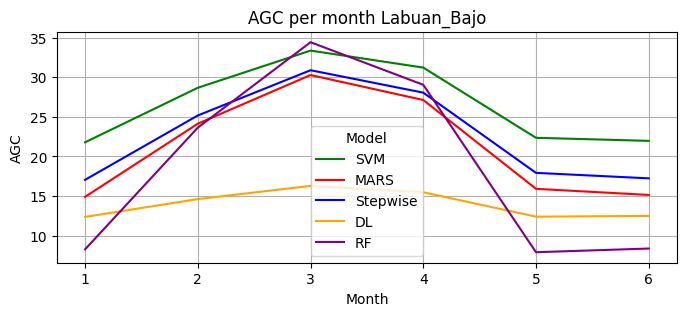

                  region    year  month        SVM       MARS   stepwise  \
45169107  Lombok_Selatan  2019.0    1.0  10.467570   3.824961   7.119509   
45169108  Lombok_Selatan  2019.0    1.0  12.614119   4.212942   7.468085   
45169109  Lombok_Selatan  2019.0    1.0  15.581720   6.044652   9.113763   
45169110  Lombok_Selatan  2019.0    1.0  13.964946   6.044652   9.113763   
45169111  Lombok_Selatan  2019.0    1.0  19.847666  11.382579  13.909558   
...                  ...     ...    ...        ...        ...        ...   
47668778  Lombok_Selatan  2021.0    6.0  13.357500   8.568421  11.381212   
47668779  Lombok_Selatan  2021.0    6.0  19.691153  15.027363  17.184169   
47668780  Lombok_Selatan  2021.0    6.0  21.143597  16.499668  18.506944   
47668781  Lombok_Selatan  2021.0    6.0   8.811610   3.935146   7.218503   
47668782  Lombok_Selatan  2021.0    6.0  17.772764  13.226273  15.566002   

          deep_learning   rf  
45169107       8.348076  0.0  
45169108       9.544951  

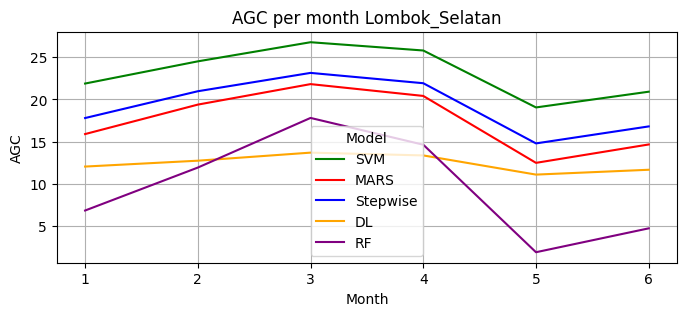

            region    year  month        SVM       MARS   stepwise  \
47668783  Mentawai  2019.0    1.0  39.521523  38.089570  37.904127   
47668784  Mentawai  2019.0    1.0  23.705337  16.523427  18.528290   
47668785  Mentawai  2019.0    1.0  25.277998  18.819741  20.591385   
47668786  Mentawai  2019.0    1.0  26.654998  20.903272  22.463308   
47668787  Mentawai  2019.0    1.0  26.267919  21.104850  22.644413   
...            ...     ...    ...        ...        ...        ...   
49979990  Mentawai  2021.0    6.0  17.674849   9.358142  12.090727   
49979991  Mentawai  2021.0    6.0  19.540969  11.612409  14.116046   
49979992  Mentawai  2021.0    6.0  21.104757  14.152297  16.397977   
49979993  Mentawai  2021.0    6.0  23.168154  16.523427  18.528290   
49979994  Mentawai  2021.0    6.0  23.676040  17.395279  19.311595   

          deep_learning      rf  
47668783      19.297003  44.002  
47668784      12.881948   0.000  
47668785      13.267650   1.796  
47668786      13.607850

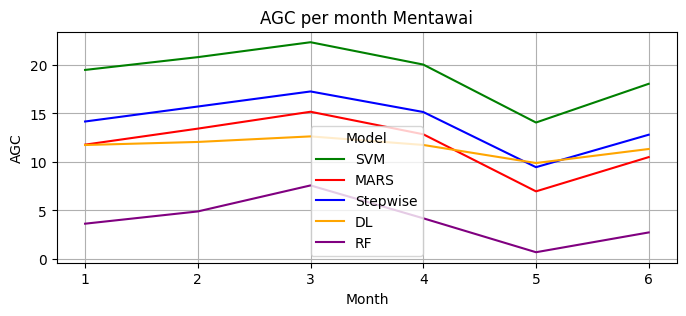

          region    year  month        SVM       MARS   stepwise  \
49979995  Parang  2019.0    1.0  15.753953   6.503108   9.525657   
49979996  Parang  2019.0    1.0  15.448165   6.135617   9.195489   
49979997  Parang  2019.0    1.0  14.952309   5.535857   8.656642   
49979998  Parang  2019.0    1.0  14.436854   5.038055   8.209398   
49979999  Parang  2019.0    1.0  14.033850   4.353108   7.594016   
...          ...     ...    ...        ...        ...        ...   
50973893  Parang  2021.0    6.0  15.224484   7.707002  10.607281   
50973894  Parang  2021.0    6.0  16.462765   9.080389  11.841184   
50973895  Parang  2021.0    6.0  19.472044  11.516370  14.029760   
50973896  Parang  2021.0    6.0  16.757085   8.737821  11.533408   
50973897  Parang  2021.0    6.0  17.836815   9.852374  12.534764   

          deep_learning   rf  
49979995      10.802549  0.0  
49979996      10.729350  0.0  
49979997      10.614036  0.0  
49979998      10.449132  0.0  
49979999      10.433990  0.0

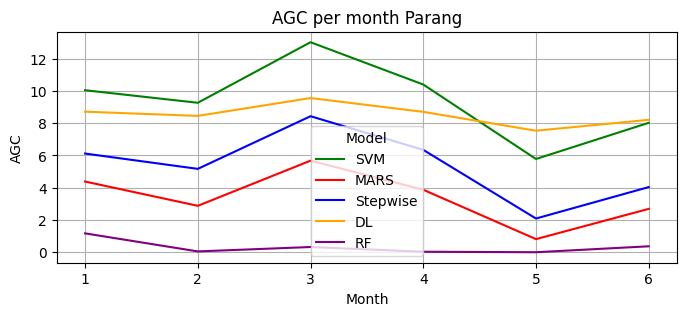

         region    year  month        SVM       MARS   stepwise  \
50973898   Rote  2019.0    1.0  37.527264  44.091684  43.296652   
50973899   Rote  2019.0    1.0  37.363394  44.792966  43.926711   
50973900   Rote  2019.0    1.0  -0.988441   0.057334  -5.297563   
50973901   Rote  2019.0    1.0   1.763526   0.057334  -2.957259   
50973902   Rote  2019.0    1.0   2.064246   0.057334  -2.645637   
...         ...     ...    ...        ...        ...        ...   
60425777   Rote  2021.0    6.0  28.900028  22.505208  23.902547   
60425778   Rote  2021.0    6.0  24.641613  18.977645  20.733252   
60425779   Rote  2021.0    6.0  25.739568  19.593025  21.286133   
60425780   Rote  2021.0    6.0  25.722614  20.845996  22.411849   
60425781   Rote  2021.0    6.0  29.177160  24.895093  26.049711   

          deep_learning      rf  
50973898      15.412837  44.002  
50973899      15.095024  44.002  
50973900       6.546435   0.000  
50973901       7.151174   0.000  
50973902       7.197206  

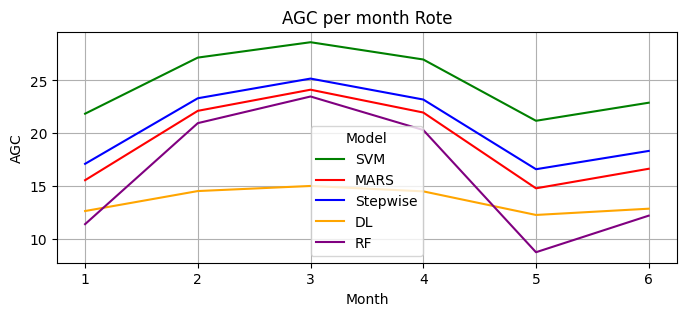

               region    year  month        SVM      MARS  stepwise  \
60425782  Ujung_Kulon  2019.0    1.0  11.877753  2.594420  6.013944   
60425783  Ujung_Kulon  2019.0    1.0   9.755900  0.445376  4.083162   
60425784  Ujung_Kulon  2019.0    1.0   9.575198  0.057409  3.734598   
60425785  Ujung_Kulon  2019.0    1.0  10.554655  0.743737  4.351221   
60425786  Ujung_Kulon  2019.0    1.0  12.429932  2.659629  6.072530   
...               ...     ...    ...        ...       ...       ...   
62326482  Ujung_Kulon  2021.0    6.0  13.778363  5.285611  8.431812   
62326483  Ujung_Kulon  2021.0    6.0  11.055475  2.922334  6.308554   
62326484  Ujung_Kulon  2021.0    6.0  12.427323  4.325006  7.568768   
62326485  Ujung_Kulon  2021.0    6.0  13.291669  5.110589  8.274566   
62326486  Ujung_Kulon  2021.0    6.0  14.073179  5.491498  8.616788   

          deep_learning   rf  
60425782       9.656775  0.0  
60425783       9.088270  0.0  
60425784       9.117564  0.0  
60425785       9.489100

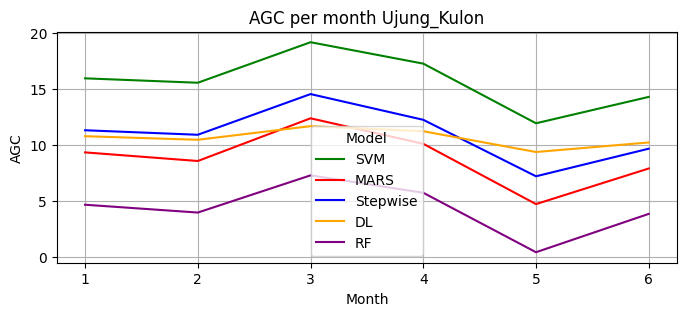

In [100]:
# Visualize per regions
for x in REGIONS:
    sample_region = sample_prediction[sample_prediction["region"] == x]
    sample_mean = sample_region.groupby("month").mean(numeric_only=True)

    mars = sample_mean["MARS"]
    svm = sample_mean["SVM"]
    stepwise = sample_mean["stepwise"]
    dl = sample_mean["deep_learning"]
    rf = sample_mean["rf"]

    plt.figure(figsize=(8, 3))
    plt.grid(False)
    plt.plot(svm, label="SVM", color="green")
    plt.plot(mars, label="MARS", color="red")
    plt.plot(stepwise, label="Stepwise", color="blue")
    plt.plot(dl, label="DL", color="orange")
    plt.plot(rf, label="RF", color="purple")
    plt.legend(title="Model")
    plt.xlabel("Month")
    plt.ylabel("AGC")
    plt.title(f"AGC per month {x}")
    plt.grid(True)
    plt.show()